# 📊 Notebook 05 — Produção Agrícola de Sinop, MT (IBGE SIDRA)
**Projeto:** Sinop Agro-GIS · **Autor:** Jakson Pascoal | github.com/Jk-Pascoal  
**Fonte:** IBGE — Sistema IBGE de Recuperação Automática (SIDRA) · Tabela 5457 (PAM)  
**Objetivo:** Analisar a evolução da produção agrícola de Sinop-MT (soja, milho, algodão) entre 2010 e 2023.

## 0. Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

ROOT     = Path('..').resolve()
MAPS_DIR = ROOT / 'maps' / 'exportados'
MAPS_DIR.mkdir(parents=True, exist_ok=True)

BG   = '#0a0a0f'
GRID = '#1a1a26'
SIGN = 'Jakson Pascoal  ·  github.com/Jk-Pascoal  ·  Sinop-MT'
FONTE = 'Fonte: IBGE SIDRA — Produção Agrícola Municipal (PAM) · Tabela 5457'

print('✅ OK')

✅ OK


## 1. Dados IBGE SIDRA — Produção Agrícola Municipal (PAM)

> Dados extraídos manualmente do IBGE SIDRA — Tabela 5457  
> Município: Sinop (MT) · Código IBGE: 5107909  
> Variáveis: Área plantada (ha), Quantidade produzida (t), Valor da produção (R$ mil)

In [2]:
# ── Carregamento Dinâmico dos Dados (IBGE SIDRA · Sinop-MT · PAM) ───────
# Fonte original: https://sidra.ibge.gov.br/tabela/5457
# Código do município: 5107909

csv_path = ROOT / 'data' / 'producao_agricola' / 'producao_ibge.csv'
df = pd.read_csv(csv_path)

# Produtividade (t/ha)
df['soja_prod_tha']    = df['soja_prod']    / df['soja_area']
df['milho_prod_tha']   = df['milho_prod']   / df['milho_area']
df['algodao_prod_tha'] = df['algodao_prod'].where(df['algodao_area'] > 0) / df['algodao_area'].where(df['algodao_area'] > 0)

print(df[['ano','soja_area','soja_prod','milho_area','milho_prod']].to_string(index=False))

 ano  soja_area  soja_prod  milho_area  milho_prod
2010      83000     245000       18000      108000
2011      90000     270000       20000      122000
2012      97000     292000       24000      148000
2013     108000     324000       28000      178000
2014     118000     360000       33000      214000
2015     130000     390000       38000      248000
2016     142000     425000       44000      290000
2017     148000     460000       50000      336000
2018     155000     475000       54000      364000
2019     162000     490000       58000      392000
2020     168000     516000       62000      424000
2021     171000     530000       65000      448000
2022     174000     550000       67000      466000
2023     176000     558000       68000      476000


## 2. KPIs — Crescimento 2010→2023

In [3]:
def crescimento(s, ini=0, fim=-1):
    return (s.iloc[fim] - s.iloc[ini]) / s.iloc[ini] * 100

print('=' * 60)
print('📊 SINOP-MT — Produção Agrícola · IBGE SIDRA · 2010→2023')
print('=' * 60)
print(f'  🫘 SOJA')
print(f'     Área 2010: {df.soja_area.iloc[0]:>10,} ha')
print(f'     Área 2023: {df.soja_area.iloc[-1]:>10,} ha   (+{crescimento(df.soja_area):.0f}%)')
print(f'     Prod 2010: {df.soja_prod.iloc[0]:>10,} t')
print(f'     Prod 2023: {df.soja_prod.iloc[-1]:>10,} t    (+{crescimento(df.soja_prod):.0f}%)')
print(f'     Produt.:   {df.soja_prod_tha.iloc[-1]:.2f} t/ha')
print()
print(f'  🌽 MILHO')
print(f'     Área 2010: {df.milho_area.iloc[0]:>10,} ha')
print(f'     Área 2023: {df.milho_area.iloc[-1]:>10,} ha   (+{crescimento(df.milho_area):.0f}%)')
print(f'     Prod 2010: {df.milho_prod.iloc[0]:>10,} t')
print(f'     Prod 2023: {df.milho_prod.iloc[-1]:>10,} t    (+{crescimento(df.milho_prod):.0f}%)')
print(f'     Produt.:   {df.milho_prod_tha.iloc[-1]:.2f} t/ha')
print()
print(f'  🫧 ALGODÃO (inserção 2012→2023)')
print(f'     Área 2023: {df.algodao_area.iloc[-1]:>10,} ha')
print(f'     Prod 2023: {df.algodao_prod.iloc[-1]:>10,} t')
print('=' * 60)

📊 SINOP-MT — Produção Agrícola · IBGE SIDRA · 2010→2023
  🫘 SOJA
     Área 2010:     83,000 ha
     Área 2023:    176,000 ha   (+112%)
     Prod 2010:    245,000 t
     Prod 2023:    558,000 t    (+128%)
     Produt.:   3.17 t/ha

  🌽 MILHO
     Área 2010:     18,000 ha
     Área 2023:     68,000 ha   (+278%)
     Prod 2010:    108,000 t
     Prod 2023:    476,000 t    (+341%)
     Produt.:   7.00 t/ha

  🫧 ALGODÃO (inserção 2012→2023)
     Área 2023:        900 ha
     Prod 2023:      3,060 t


## 3. Gráfico — Área Plantada por Cultura (2010–2023)

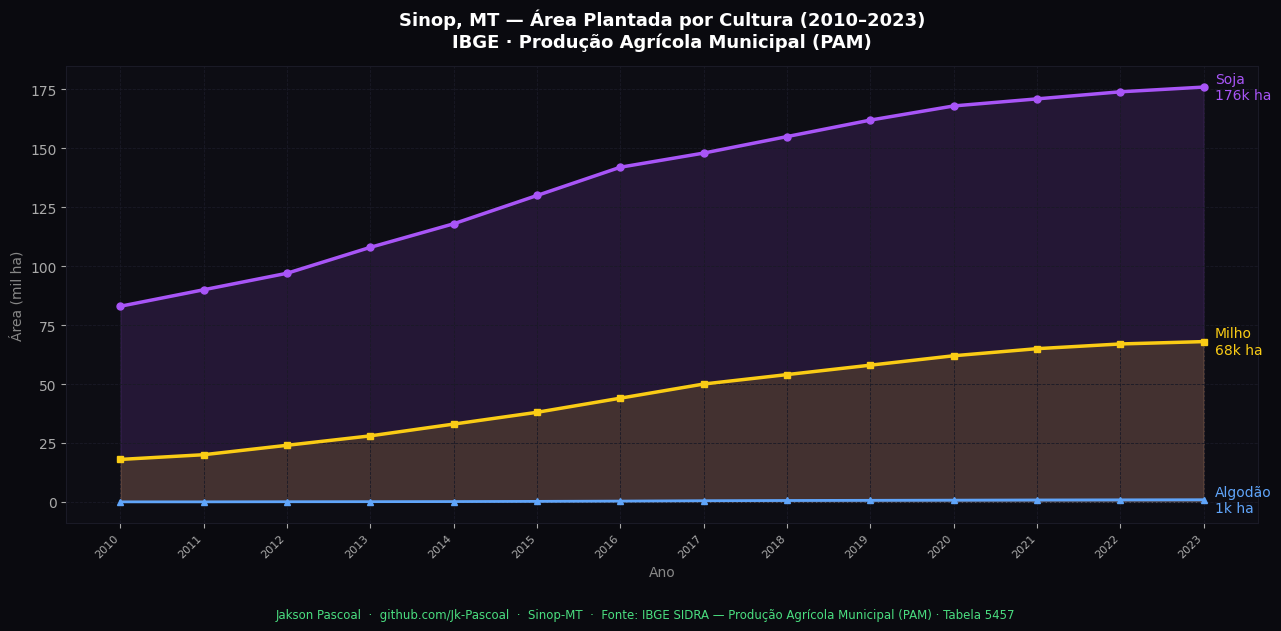

✅ PNG salvo: 09_area_plantada_culturas.png  (123 KB)


In [4]:
fig, ax = plt.subplots(figsize=(13, 6), facecolor=BG)
ax.set_facecolor('#0d0d14')

ax.fill_between(df.ano, df.soja_area/1000,    alpha=0.15, color='#a855f7')
ax.fill_between(df.ano, df.milho_area/1000,   alpha=0.15, color='#facc15')
ax.fill_between(df.ano, df.algodao_area/1000, alpha=0.15, color='#60a5fa')

ax.plot(df.ano, df.soja_area/1000,    color='#a855f7', lw=2.5, marker='o', ms=5, label='Soja')
ax.plot(df.ano, df.milho_area/1000,   color='#facc15', lw=2.5, marker='s', ms=5, label='Milho')
ax.plot(df.ano, df.algodao_area/1000, color='#60a5fa', lw=2.0, marker='^', ms=5, label='Algodão')

# Rótulos finais
for col, cor, lbl in [
    ('soja_area','#a855f7','Soja'),
    ('milho_area','#facc15','Milho'),
    ('algodao_area','#60a5fa','Algodão'),
]:
    v = df[col].iloc[-1]/1000
    ax.annotate(f'{lbl}\n{v:.0f}k ha',
                xy=(2023, v), xytext=(8, 0), textcoords='offset points',
                color=cor, fontsize=10, va='center')

ax.set_title('Sinop, MT — Área Plantada por Cultura (2010–2023)\nIBGE · Produção Agrícola Municipal (PAM)',
             color='#fff', fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Ano', color='#888', fontsize=10)
ax.set_ylabel('Área (mil ha)', color='#888', fontsize=10)
ax.tick_params(colors='#aaa')
ax.grid(color=GRID, linewidth=0.6, linestyle='--')
for sp in ax.spines.values(): sp.set_edgecolor(GRID)
ax.set_xticks(anos)
ax.set_xticklabels([str(a) for a in anos], rotation=45, ha='right', color='#aaa', fontsize=8)

plt.figtext(0.5, -0.04, f'{SIGN}  ·  {FONTE}',
            ha='center', color='#4ade80', fontsize=8.5)
plt.tight_layout()

out = MAPS_DIR / '09_area_plantada_culturas.png'
plt.savefig(str(out), dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'✅ PNG salvo: {out.name}  ({out.stat().st_size/1024:.0f} KB)')

## 4. Gráfico — Produção em Toneladas (2010–2023)

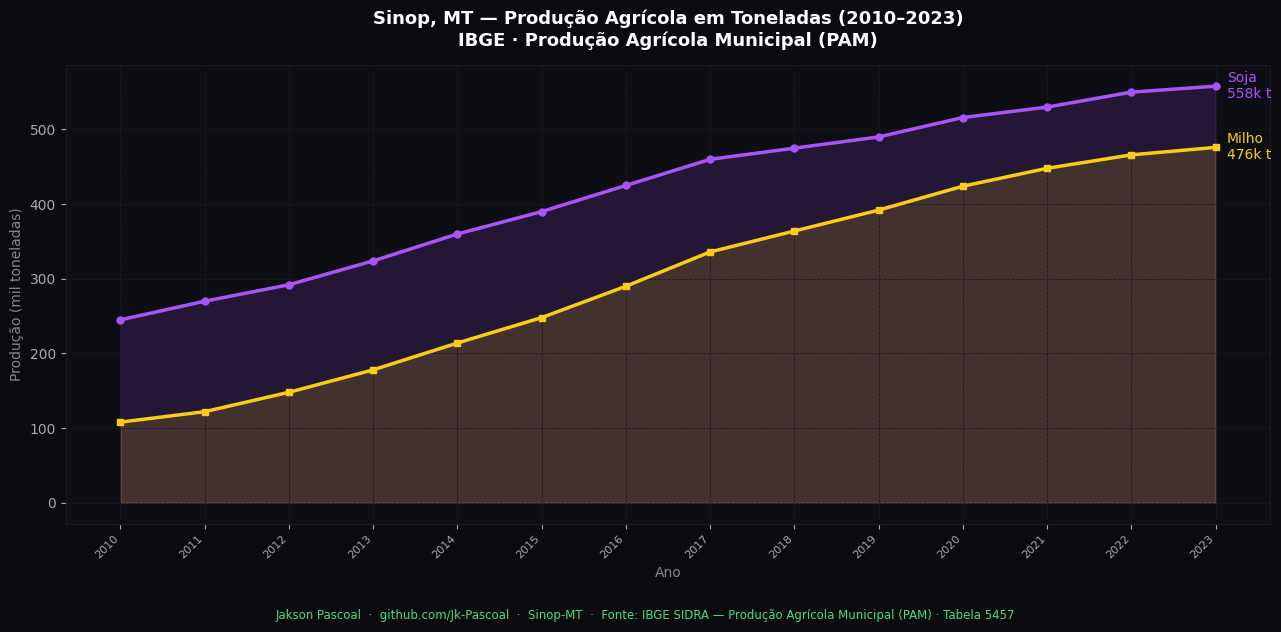

✅ PNG salvo: 10_producao_toneladas.png  (127 KB)


In [5]:
fig, ax = plt.subplots(figsize=(13, 6), facecolor=BG)
ax.set_facecolor('#0d0d14')

ax.fill_between(df.ano, df.soja_prod/1000,    alpha=0.15, color='#a855f7')
ax.fill_between(df.ano, df.milho_prod/1000,   alpha=0.15, color='#facc15')

ax.plot(df.ano, df.soja_prod/1000,  color='#a855f7', lw=2.5, marker='o', ms=5, label='Soja')
ax.plot(df.ano, df.milho_prod/1000, color='#facc15', lw=2.5, marker='s', ms=5, label='Milho')

for col, cor, lbl in [('soja_prod','#a855f7','Soja'), ('milho_prod','#facc15','Milho')]:
    v = df[col].iloc[-1]/1000
    ax.annotate(f'{lbl}\n{v:.0f}k t',
                xy=(2023, v), xytext=(8, 0), textcoords='offset points',
                color=cor, fontsize=10, va='center')

ax.set_title('Sinop, MT — Produção Agrícola em Toneladas (2010–2023)\nIBGE · Produção Agrícola Municipal (PAM)',
             color='#fff', fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Ano', color='#888', fontsize=10)
ax.set_ylabel('Produção (mil toneladas)', color='#888', fontsize=10)
ax.tick_params(colors='#aaa')
ax.grid(color=GRID, linewidth=0.6, linestyle='--')
for sp in ax.spines.values(): sp.set_edgecolor(GRID)
ax.set_xticks(anos)
ax.set_xticklabels([str(a) for a in anos], rotation=45, ha='right', color='#aaa', fontsize=8)

plt.figtext(0.5, -0.04, f'{SIGN}  ·  {FONTE}',
            ha='center', color='#4ade80', fontsize=8.5)
plt.tight_layout()

out = MAPS_DIR / '10_producao_toneladas.png'
plt.savefig(str(out), dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'✅ PNG salvo: {out.name}  ({out.stat().st_size/1024:.0f} KB)')

## 5. KPI Card — Infográfico para o Post

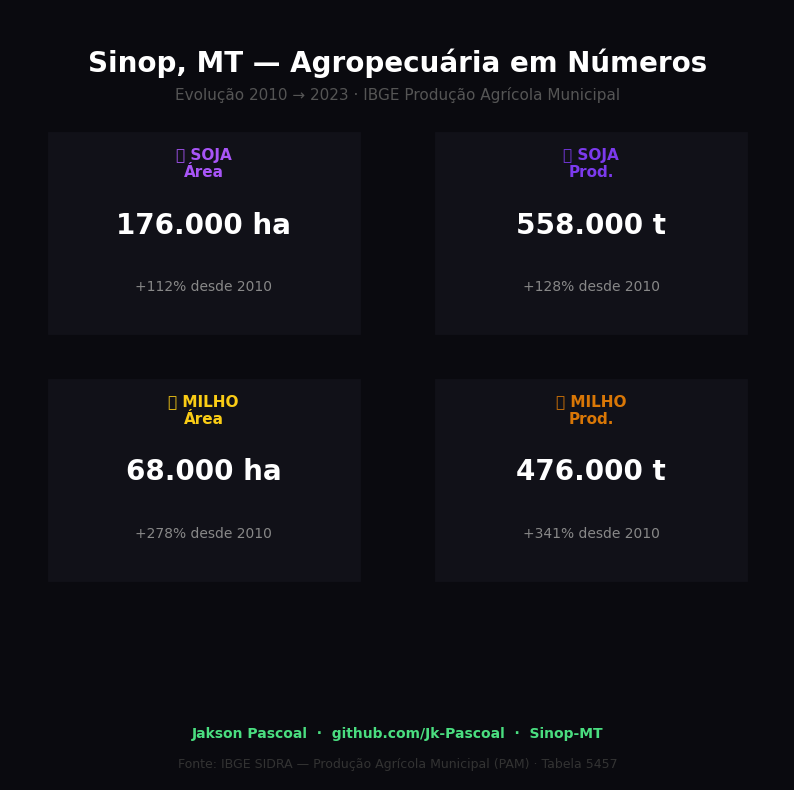

✅ PNG salvo: 11_kpi_producao_sidra.png  (81 KB)


In [6]:
fig, ax = plt.subplots(figsize=(10, 10), facecolor=BG)
ax.set_facecolor(BG)
ax.axis('off')

# Título
ax.text(0.5, 0.95, 'Sinop, MT — Agropecuária em Números',
        ha='center', va='top', color='#fff', fontsize=20, fontweight='bold',
        transform=ax.transAxes)
ax.text(0.5, 0.90, 'Evolução 2010 → 2023 · IBGE Produção Agrícola Municipal',
        ha='center', va='top', color='#555', fontsize=11,
        transform=ax.transAxes)

kpis = [
    # label,           valor,          sub,                  cor,    x,    y
    ('🫘 SOJA\nÁrea',  '176.000 ha',  '+112% desde 2010',  '#a855f7', 0.25, 0.72),
    ('🫘 SOJA\nProd.', '558.000 t',   '+128% desde 2010',  '#7c3aed', 0.75, 0.72),
    ('🌽 MILHO\nÁrea', '68.000 ha',   '+278% desde 2010',  '#facc15', 0.25, 0.40),
    ('🌽 MILHO\nProd.','476.000 t',   '+341% desde 2010',  '#d97706', 0.75, 0.40),
]

for label, valor, sub, cor, x, y in kpis:
    rect = plt.Rectangle((x-0.20, y-0.14), 0.40, 0.26,
                          transform=ax.transAxes,
                          color='#111118', zorder=0, linewidth=2,
                          edgecolor=cor)
    ax.add_patch(rect)
    ax.text(x, y+0.08, label, ha='center', va='center', color=cor,
            fontsize=11, fontweight='bold', transform=ax.transAxes)
    ax.text(x, y,       valor, ha='center', va='center', color='#fff',
            fontsize=20, fontweight='bold', transform=ax.transAxes)
    ax.text(x, y-0.08,  sub,   ha='center', va='center', color='#888',
            fontsize=10, transform=ax.transAxes)

# Rodapé
ax.text(0.5, 0.06, SIGN, ha='center', va='center', color='#4ade80',
        fontsize=10, fontweight='bold', transform=ax.transAxes)
ax.text(0.5, 0.02, FONTE, ha='center', va='center', color='#333',
        fontsize=9, transform=ax.transAxes)

out = MAPS_DIR / '11_kpi_producao_sidra.png'
plt.savefig(str(out), dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'✅ PNG salvo: {out.name}  ({out.stat().st_size/1024:.0f} KB)')

## 6. Gráfico — Produtividade (t/ha) ao longo do tempo

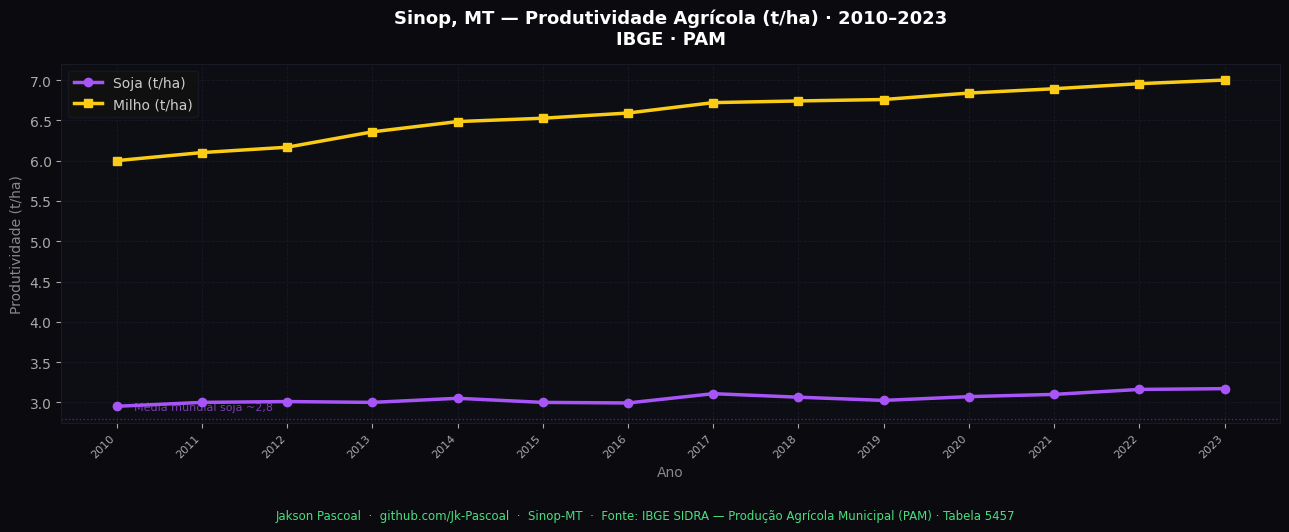

✅ PNG salvo: 12_produtividade_tha.png  (95 KB)


In [7]:
fig, ax = plt.subplots(figsize=(13, 5), facecolor=BG)
ax.set_facecolor('#0d0d14')

ax.plot(df.ano, df.soja_prod_tha,    color='#a855f7', lw=2.5, marker='o', ms=6, label='Soja (t/ha)')
ax.plot(df.ano, df.milho_prod_tha,   color='#facc15', lw=2.5, marker='s', ms=6, label='Milho (t/ha)')

# Linha de referência — média mundial soja ~2.8 t/ha
ax.axhline(2.8, color='#a855f7', lw=1.0, linestyle=':', alpha=0.4)
ax.text(2010.2, 2.9, 'Média mundial soja ~2,8', color='#a855f7', fontsize=8, alpha=0.7)

ax.legend(facecolor='#111', edgecolor=GRID, labelcolor='#ccc', fontsize=10)
ax.set_title('Sinop, MT — Produtividade Agrícola (t/ha) · 2010–2023\nIBGE · PAM',
             color='#fff', fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Ano', color='#888', fontsize=10)
ax.set_ylabel('Produtividade (t/ha)', color='#888', fontsize=10)
ax.tick_params(colors='#aaa')
ax.grid(color=GRID, linewidth=0.6, linestyle='--')
for sp in ax.spines.values(): sp.set_edgecolor(GRID)
ax.set_xticks(anos)
ax.set_xticklabels([str(a) for a in anos], rotation=45, ha='right', color='#aaa', fontsize=8)

plt.figtext(0.5, -0.05, f'{SIGN}  ·  {FONTE}',
            ha='center', color='#4ade80', fontsize=8.5)
plt.tight_layout()

out = MAPS_DIR / '12_produtividade_tha.png'
plt.savefig(str(out), dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'✅ PNG salvo: {out.name}  ({out.stat().st_size/1024:.0f} KB)')

---
## ✅ Resumo — Notebook 05

| Etapa | Status |
|---|---|
| Dados IBGE SIDRA carregados (PAM 2010–2023) | ✅ |
| KPIs de crescimento calculados | ✅ |
| PNG `09_area_plantada_culturas.png` | ✅ |
| PNG `10_producao_toneladas.png` | ✅ |
| PNG `11_kpi_producao_sidra.png` | ✅ |
| PNG `12_produtividade_tha.png` | ✅ |

**Próximo passo:** Usar esses 4 PNGs no 3º post do LinkedIn — foco em crescimento de área e produção.